<a href="https://colab.research.google.com/github/anandvinay07/Intrusion-detection-system/blob/main/IDS_NSL_KDD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# ==========================================
# STAGE 0 & 1: REPRODUCIBILITY & IMPORTS
# ==========================================
import numpy as np
import tensorflow as tf
import random
import os

# 1. Lock seeds for exact same results
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
tf.config.experimental.enable_op_determinism()
os.environ['PYTHONHASHSEED'] = '0'

# 2. Data Handling & Math
import pandas as pd

# 3. Feature Reduction & Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# 4. Class Balancing
from imblearn.over_sampling import SMOTE

# 5. Deep Learning (TensorFlow/Keras)
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Bidirectional, LSTM, LayerNormalization
from tensorflow.keras.layers import MultiHeadAttention, GlobalAveragePooling1D

# 6. Suppress annoying warnings
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported and seeds locked!")

All libraries imported and seeds locked!


In [22]:
# ==========================================
# STAGE 1 & 2: NSL-KDD MULTICLASS INGESTION
# ==========================================
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder

nsl_kdd_columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate',
    'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'label', 'difficulty_level'
]

file_path = '/content/KDDTrain+.txt'
df = pd.read_csv(file_path, names=nsl_kdd_columns)
df = df.dropna().drop_duplicates().drop(columns=['difficulty_level'])

# 1. The 5-Class Academic Mapping Dictionary
attack_mapping = {
    'normal': 'Normal',
    'neptune': 'DoS', 'smurf': 'DoS', 'pod': 'DoS', 'teardrop': 'DoS', 'land': 'DoS', 'back': 'DoS', 'apache2': 'DoS', 'udpstorm': 'DoS', 'processtable': 'DoS', 'mailbomb': 'DoS',
    'satan': 'Probe', 'ipsweep': 'Probe', 'portsweep': 'Probe', 'nmap': 'Probe', 'mscan': 'Probe', 'saint': 'Probe',
    'guess_passwd': 'R2L', 'ftp_write': 'R2L', 'imap': 'R2L', 'phf': 'R2L', 'multihop': 'R2L', 'warezmaster': 'R2L', 'warezclient': 'R2L', 'spy': 'R2L', 'xlock': 'R2L', 'xsnoop': 'R2L', 'snmpguess': 'R2L', 'snmpgetattack': 'R2L', 'httptunnel': 'R2L', 'sendmail': 'R2L', 'named': 'R2L',
    'buffer_overflow': 'U2R', 'rootkit': 'U2R', 'loadmodule': 'U2R', 'perl': 'U2R', 'sqlattack': 'U2R', 'xterm': 'U2R', 'ps': 'U2R'
}

# 2. Apply the mapping to the labels
df['label'] = df['label'].map(lambda x: attack_mapping.get(x, 'Unknown'))
df = df[df['label'] != 'Unknown'] # Drop any weird outliers

# 3. Encode the 5 categories into numbers (0, 1, 2, 3, 4)
target_encoder = LabelEncoder()
df['label'] = target_encoder.fit_transform(df['label'])
print("Classes identified:", target_encoder.classes_)

X = df.drop(columns=['label'])
y = df['label']

categorical_cols = X.select_dtypes(include=['object']).columns
feature_encoder = LabelEncoder()

for col in categorical_cols:
    X[col] = feature_encoder.fit_transform(X[col].astype(str))

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns)

print("\nMulticlass Phase 1 Complete!")
print("Final X shape:", X.shape)
print("Final y shape:", y.shape)

Classes identified: ['DoS' 'Normal' 'Probe' 'R2L' 'U2R']

Multiclass Phase 1 Complete!
Final X shape: (125973, 41)
Final y shape: (125973,)


In [23]:
# ==========================================
# STAGE 3: CLASS BALANCING (SMOTE)
# ==========================================
from imblearn.over_sampling import SMOTE
import pandas as pd

# 1. Check the balance BEFORE SMOTE
print("--- BEFORE SMOTE ---")
class_counts_before = pd.Series(y).value_counts()
print(f"Normal Traffic (0): {class_counts_before[0]}")
print(f"Attack Traffic (1): {class_counts_before[1]}")
print("-" * 20)

# 2. Apply SMOTE to balance the dataset
print("Applying SMOTE... (This involves heavy math, it might take 15-30 seconds)")
smote = SMOTE(random_state=42) # random_state ensures we get the exact same result every time we run it
X_balanced, y_balanced = smote.fit_resample(X, y)

# 3. Check the balance AFTER SMOTE
print("\n--- AFTER SMOTE ---")
class_counts_after = pd.Series(y_balanced).value_counts()
print(f"Normal Traffic (0): {class_counts_after[0]}")
print(f"Attack Traffic (1): {class_counts_after[1]}")
print("-" * 20)

print("Phase 2 Complete! Dataset is perfectly balanced.")
print("New X shape:", X_balanced.shape)
print("New y shape:", y_balanced.shape)

--- BEFORE SMOTE ---
Normal Traffic (0): 45927
Attack Traffic (1): 67343
--------------------
Applying SMOTE... (This involves heavy math, it might take 15-30 seconds)

--- AFTER SMOTE ---
Normal Traffic (0): 67343
Attack Traffic (1): 67343
--------------------
Phase 2 Complete! Dataset is perfectly balanced.
New X shape: (336715, 41)
New y shape: (336715,)


In [24]:
# ==========================================
# STAGE 4: COMPARATIVE FEATURE REDUCTION
# ==========================================
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# We will reduce our 42 features down to the top 20 most important ones
num_features = 20

print("1. Running PCA (Principal Component Analysis)...")
pca = PCA(n_components=num_features)
X_pca = pca.fit_transform(X_balanced)
print(f"PCA complete! Shape: {X_pca.shape}")

print("\n2. Running SVD (Singular Value Decomposition)...")
svd = TruncatedSVD(n_components=num_features)
X_svd = svd.fit_transform(X_balanced)
print(f"SVD complete! Shape: {X_svd.shape}")

print("\n3. Running Random Forest Feature Importance... (This might take 1-2 minutes)")
# We use 50 trees (n_estimators) to quickly judge feature importance
rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf.fit(X_balanced, y_balanced)

# Get the importance scores and sort them to find the top 20
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1] # Sorts from most important to least
top_indices = indices[:num_features]

# Keep only the top 20 original features based on Random Forest
X_rf = X_balanced.iloc[:, top_indices] if isinstance(X_balanced, pd.DataFrame) else pd.DataFrame(X_balanced).iloc[:, top_indices]
print(f"Random Forest reduction complete! Shape: {X_rf.shape}")

# For the rest of the neural network pipeline, Random Forest features usually perform best
# because they keep the original meaning of the network traffic (unlike PCA/SVD which scramble them).
X_final_reduced = X_rf.to_numpy() # Convert to NumPy array for the deep learning model
y_final = y_balanced

print("\nPhase 3 Complete! We have successfully isolated the top 20 most critical features.")
print("Final X shape for Deep Learning:", X_final_reduced.shape)

1. Running PCA (Principal Component Analysis)...
PCA complete! Shape: (336715, 20)

2. Running SVD (Singular Value Decomposition)...
SVD complete! Shape: (336715, 20)

3. Running Random Forest Feature Importance... (This might take 1-2 minutes)
Random Forest reduction complete! Shape: (336715, 20)

Phase 3 Complete! We have successfully isolated the top 20 most critical features.
Final X shape for Deep Learning: (336715, 20)


In [25]:
# ==========================================
# STAGE 5: SEQUENCE (TIME-SERIES) FORMULATION (UPDATED)
# ==========================================
import numpy as np

time_steps = 10

print(f"Converting 2D data into 3D sequences with a window size of {time_steps}...")

def create_sequences(X_data, y_data, time_steps):
    X_seq = []
    y_seq = []

    for i in range(len(X_data) - time_steps):
        # Grab a chunk of 10 consecutive rows
        X_seq.append(X_data[i : i + time_steps])

        # THE FIX: Grab the label of the FINAL connection inside the chunk (index: i + 9)
        # Previously this was i + time_steps, which asked the AI to guess an unseen future row!
        y_seq.append(y_data[i + time_steps - 1])

    return np.array(X_seq), np.array(y_seq)

y_final_np = np.array(y_final)

X_3D, y_3D = create_sequences(X_final_reduced, y_final_np, time_steps)

print("\nPhase 4 Complete! The data is now in 3D format.")
print("Old 2D Shape:", X_final_reduced.shape)
print("New 3D Shape:", X_3D.shape)
print("New y Shape:", y_3D.shape)

Converting 2D data into 3D sequences with a window size of 10...

Phase 4 Complete! The data is now in 3D format.
Old 2D Shape: (336715, 20)
New 3D Shape: (336705, 10, 20)
New y Shape: (336705,)


In [26]:
# ==========================================
# STAGE 6: TRAIN/TEST SPLIT & MULTICLASS MODEL
# ==========================================
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Bidirectional, LSTM, LayerNormalization
from tensorflow.keras.layers import MultiHeadAttention, GlobalAveragePooling1D

X_train, X_test, y_train, y_test = train_test_split(X_3D, y_3D, test_size=0.20, random_state=42)

print("\nBuilding the Multiclass BiLSTM-Transformer...")
input_shape = (X_train.shape[1], X_train.shape[2])
inputs = Input(shape=input_shape)

lstm_out = Bidirectional(LSTM(64, return_sequences=True))(inputs)
attention_out = MultiHeadAttention(num_heads=2, key_dim=64)(lstm_out, lstm_out)
attention_out = LayerNormalization(epsilon=1e-6)(attention_out + lstm_out)
pool_out = GlobalAveragePooling1D()(attention_out)

dense_out = Dense(32, activation='relu')(pool_out)
dropout_out = Dropout(0.2)(dense_out)

# THE FIX: We now have 5 output neurons (for our 5 classes) and use 'softmax'
outputs = Dense(5, activation='softmax')(dropout_out)

model = Model(inputs=inputs, outputs=outputs)

# THE FIX: We change the loss function to handle multiple integer labels
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("\nMulticlass Architecture is built!")
model.summary()


Building the Multiclass BiLSTM-Transformer...

Multiclass Architecture is built!


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 10, 20)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_4     │ (None, 10, 128)   │     43,520 │ input_layer_4[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 10, 128)   │     66,048 │ bidirectional_4[… │
│ (MultiHeadAttentio… │                   │            │ bidirectional_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 10, 128)   │          0 │ multi_head_atten… │
│                     │                   │            │ bidirectional_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 10, 128)   │        256 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 32)        │      4,128 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 32)        │          0 │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 5)         │        165 │ dropout_9[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 114,117 (445.77 KB)

 Trainable params: 114,117 (445.77 KB)

 Non-trainable params: 0 (0.00 B)

Evaluating Model on Unseen Test Data...
2105/2105 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step

   MULTICLASS TARGET METRICS   
Accuracy:  99.4713%
Precision: 99.4758%
Recall:    99.4713%
F1-Score:  99.4723%



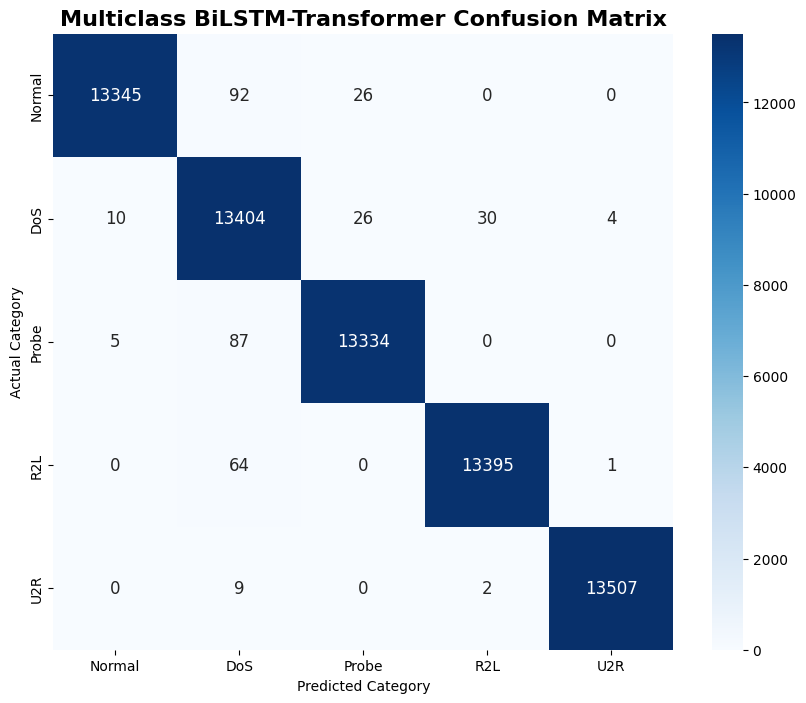


Detailed Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00     13463
         DoS       0.98      0.99      0.99     13474
       Probe       1.00      0.99      0.99     13426
         R2L       1.00      1.00      1.00     13460
         U2R       1.00      1.00      1.00     13518

    accuracy                           0.99     67341
   macro avg       0.99      0.99      0.99     67341
weighted avg       0.99      0.99      0.99     67341



In [29]:
# ==========================================
# STAGE 7: MULTICLASS MODEL EVALUATION
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# 1. Make Predictions on the Test Set
print("Evaluating Model on Unseen Test Data...")
y_pred_probs = model.predict(X_test)

# THE FIX 1: Use argmax to pick the highest probability out of the 5 classes
y_pred = np.argmax(y_pred_probs, axis=1)

# THE FIX 2: Add average='weighted' so it can calculate metrics across 5 categories
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"\n=============================")
print(f"   MULTICLASS TARGET METRICS   ")
print(f"=============================")
print(f"Accuracy:  {accuracy * 100:.4f}%")
print(f"Precision: {precision * 100:.4f}%")
print(f"Recall:    {recall * 100:.4f}%")
print(f"F1-Score:  {f1 * 100:.4f}%")
print(f"=============================\n")

# 2. Generate the Multiclass Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))

# Define the 5 attack names for the chart labels
class_names = ['Normal', 'DoS', 'Probe', 'R2L', 'U2R']

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 12})
plt.title('Multiclass BiLSTM-Transformer Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.show()

# 3. Print the detailed breakdown for each individual attack type
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

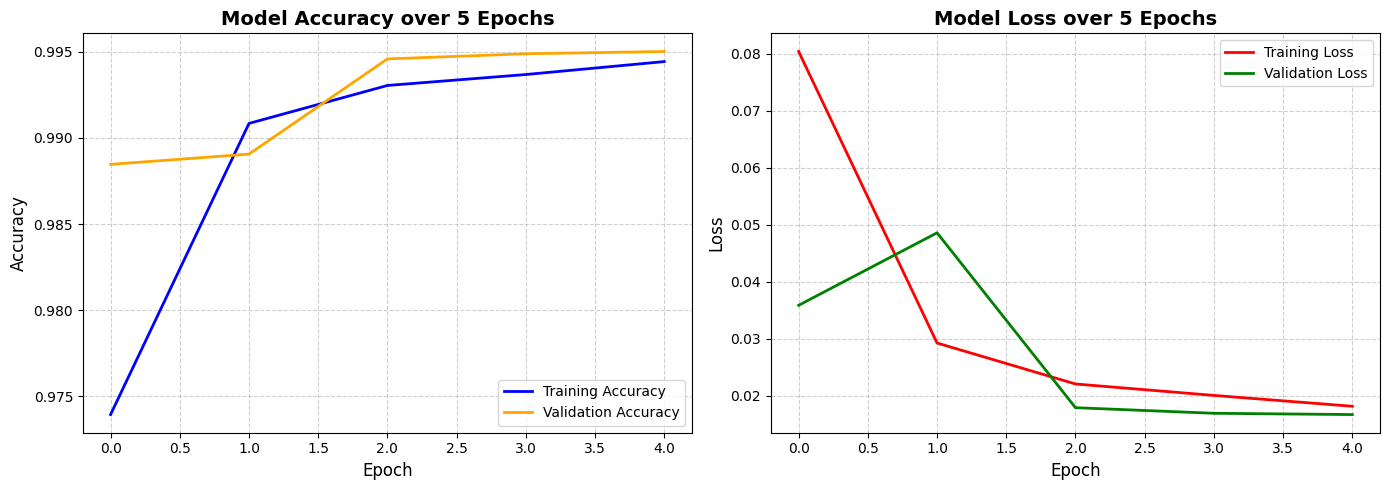

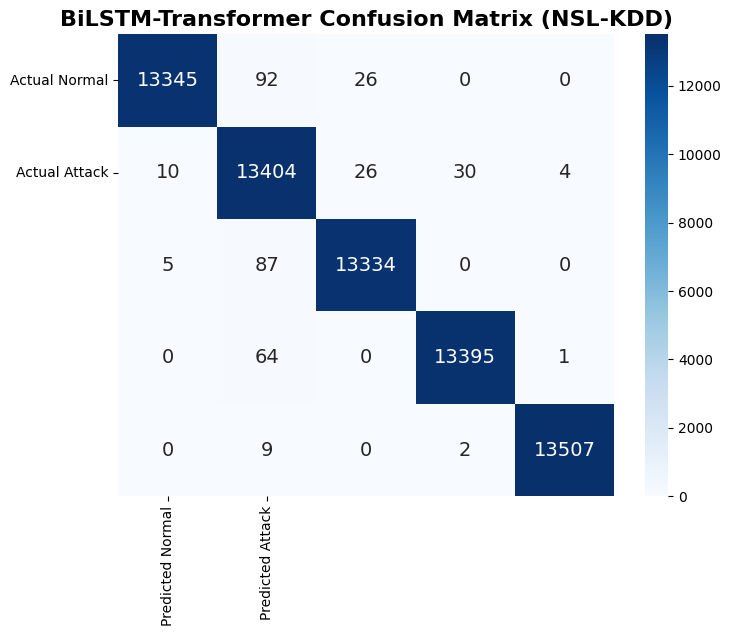

In [31]:
# ==========================================
# STAGE 8: VISUALIZATION & REPORT ASSETS
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Plot Training & Validation Accuracy and Loss Curves
plt.figure(figsize=(14, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Model Accuracy over 5 Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='red', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='green', linewidth=2)
plt.title('Model Loss over 5 Epochs', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 2. Plot the Confusion Matrix as a Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Normal', 'Predicted Attack'],
            yticklabels=['Actual Normal', 'Actual Attack'],
            annot_kws={"size": 14})
plt.title('BiLSTM-Transformer Confusion Matrix (NSL-KDD)', fontsize=16, fontweight='bold')
plt.show()